# Laboratory 5 instruction part 2 - MLflow

In machine learning development, one of the most challenging aspects is maintaining reproducibility. This issue is particularly relevant to the experimental phase, when a lot of small, but influential code changes are constantly introduced.

After extensive experimentation with different model architectures, hyperparameters, and preprocessing techniques, researchers often find themselves unable to recreate their best-performing models because critical configuration details were not properly recorded.

## MLflow

[MLflow is an open-source platform](https://mlflow.org/) that addresses this challenge by providing systematic experiment tracking throughout the machine learning lifecycle. It automatically captures configurations, metrics, and artifacts from each model training run, transforming ad-hoc model development into a structured, reproducible process. In this notebook, we will learn how to use MLflow to properly track experiments for both traditional machine learning and deep learning workflows.


### Laboratory plan

1. **MLflow tracking server** configuration and deployment for experiment management
2. **Automatic logging mechanisms** for scikit-learn experiments
3. **Manual logging implementation** for PyTorch deep learning workflows
4. **Hyperparameter optimization exercise** - systematic hyperparameter exploration
5. **Best practices** for experiment organization, versioning, and cross-team reproducibility


## 1. MLflow Tracking server configuration

[MLflow Tracking](https://mlflow.org/docs/latest/tracking/) is the main component of MLflow, responsible for capturing, storing, and presenting metrics, logs, and other tracking data. MLflow is based on a client-server architecture, where the central MLflow server can serve potentially whole teams of data scientists. You can also simply run it as a local server from the commandline, as we will now.

You have two options for running MLflow:

#### Option 1: Local MLflow (Simple)
1. Open terminal - we recommend to split it into 2 shells or just open additional session.

1. Create a directory for MLflow artifacts storage:
```bash
mkdir mlflow-artifacts
```

2. Start the MLflow tracking server:
```bash
mlflow server \
  --backend-store-uri sqlite:///mlflow.db \
  --default-artifact-root ./mlflow-artifacts \
  --host 0.0.0.0 \
  --port 5001
```


**Important: Keep this terminal window open.** The MLflow server will continue running and be accessible at http://localhost:5001

#### Option 2: MLflow with Docker (Recommended for production-like setup)

1. Create a `docker-compose.yml` file:
```yaml
services:
  mlflow:
    image: ghcr.io/mlflow/mlflow:v2.9.2
    container_name: mlflow-server
    ports:
      - "5001:5000"
    volumes:
      - ./mlflow-data:/mlflow
    command:
      - mlflow
      - server
      - --backend-store-uri
      - sqlite:////mlflow/mlflow.db
      - --default-artifact-root
      - /mlflow/artifacts
      - --host
      - 0.0.0.0
      - --port
      - "5000"
    restart: unless-stopped
```

2. Start MLflow with Docker:
```bash
docker compose down -v
rm -rf mlflow-data
mkdir -p mlflow-data/artifacts
docker compose up -d
```

3. Check if it's running:
```bash
docker-compose ps
```

4. View logs (optional):
```bash
docker-compose logs -f mlflow
```

5. To stop the server later:
```bash
docker-compose down
```

**Important: Add MLflow files to .gitignore**

MLflow creates local files that should not be committed to Git. Add these lines to your `.gitignore`:

```
# MLflow
mlflow.db
mlflow-artifacts/
mlruns/
```

These files contain experiment data and artifacts that are specific to your local machine. In production, you would use a remote tracking server and artifact storage (like S3).

### Connecting to MLflow

To verify if the server runs properly, let's connect to it:

```python
import mlflow
import mlflow.sklearn

import warnings

warnings.filterwarnings("ignore")

mlflow.set_tracking_uri("http://localhost:5001")
print(f"Connected to MLflow at: {mlflow.get_tracking_uri()}")
```

**To stop the MLflow server later:**

- **Local setup**: Press `Ctrl+C` in the terminal where it's running
- **Docker setup**: Run `docker-compose down`

The server will shut down gracefully and save all your experiments.

**Note:** Keep the server running throughout this lab session. All your experiments will be logged to this server instance.


In [1]:
import mlflow
import mlflow.sklearn

import warnings

warnings.filterwarnings("ignore")

mlflow.set_tracking_uri("http://localhost:5001")
print(f"Connected to MLflow at: {mlflow.get_tracking_uri()}")

Connected to MLflow at: http://localhost:5001


## 2. Automatic logging with scikit-learn

### 2.1 Dataset preparation

In this section, we'll use the Ames Housing dataset to demonstrate MLflow's autologging capabilities with scikit-learn. Since we have already prepared the 2006-2008 data using DVC, we can use our preprocessed dataset here. 

In [2]:
import numpy as np
import pandas as pd

from feature_engine.encoding import RareLabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

In [16]:
df = pd.read_parquet("data/ames_data_2006_2008.parquet")

df = df.sort_values(by=["YrSold"])

# As we have temporal data, the best way to evaluate our model is time (chronological) 
# split, where the newest data is used for testing. We will assume that we have the 
# data #for years 2006 and 2007, and evaluate using data from 2008.

df_train = df[df["YrSold"] < 2008]
df_test = df[df["YrSold"] == 2008]

y_train = df_train.pop("SalePrice")
y_test = df_test.pop("SalePrice")

categorical_features = df_train.select_dtypes(include="object").columns
numerical_features = df_train.select_dtypes(exclude="object").columns

In [4]:
median_imputer = SimpleImputer(strategy="median")
min_max_scaler = MinMaxScaler()
rare_encoder = RareLabelEncoder(tol=0.01, n_categories=0)
one_hot_encoder = OneHotEncoder(
    drop="first", sparse_output=False, handle_unknown="ignore"
)

num_pipeline = Pipeline(
    [("median_imputer", median_imputer), ("min_max_scaler", min_max_scaler)]
)

cat_pipeline = Pipeline(
    [("rare_encoder", rare_encoder), ("one_hot_encoder", one_hot_encoder)]
)

column_transformer = ColumnTransformer(
    [
        ("num_pipeline", num_pipeline, numerical_features),
        ("cat_pipeline", cat_pipeline, categorical_features),
    ],
    verbose_feature_names_out=False,
)
column_transformer.fit(df_train)

X_train = column_transformer.transform(df_train)
X_test = column_transformer.transform(df_test)

In [5]:
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

Training samples: 1312
Test samples: 621
Number of features: 181


### 2.2 Training with MLflow autologging

Autologging is a powerful built-in capability of MLflow, enabling fully automated and near-zero code integration of MLflow with many popular frameworks. In particular, it works really well with scikit-learn, thanks to its highly unified API. Let's try this out - we will enable autologging, and then train a bunch of different models.

In [6]:
mlflow.sklearn.autolog(
    log_input_examples=True, log_model_signatures=True, log_models=False, silent=False
)

mlflow.set_experiment("ames-housing-autolog")

2026/03/19 20:32:23 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 0.24.1 <= scikit-learn <= 1.6.1, but the installed version is 1.7.0. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.


<Experiment: artifact_location='/home/annacz/PyCharmMiscProject/ipum-lab05/mlflow-artifacts/1', creation_time=1773944828886, experiment_id='1', last_update_time=1773944828886, lifecycle_stage='active', name='ames-housing-autolog', tags={}>

In [7]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

models = [
    ("Ridge Regression", Ridge()),
    ("Decision Tree", DecisionTreeRegressor(max_depth=10, random_state=42)),
    ("K-Nearest Neighbors", KNeighborsRegressor(n_neighbors=10)),
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Gradient Boosting", GradientBoostingRegressor(n_estimators=100, random_state=42)),
]

In [8]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

def fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test):
    results_v2 = {}

    for model_name, model in models:
        # start MLflow run - a unit grouping logs from different model runs
        # everything within this context manager will get logged as a run
        with mlflow.start_run(run_name=model_name):
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            rmse = root_mean_squared_error(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()
            
            # log additional custom metrics, in addition to autologging
            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)

            results_v2[model_name] = {
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
                "cv_r2_mean": cv_mean,
            }

            print(f"\n{model_name}:")
            print(f"  RMSE: {rmse:.2f}")
            print(f"  MAE: {mae:.2f}")
            print(f"  R^2: {r2:.3f}")
            print(f"  CV R^2 (mean ± std): {cv_mean:.3f} ± {cv_std:.3f}")

In [9]:
fit_sklearn_models_with_cv(models, X_train, X_test, y_train, y_test)


Ridge Regression:
  RMSE: 23450.39
  MAE: 16430.79
  R^2: 0.904
  CV R^2 (mean ± std): 0.880 ± 0.041
🏃 View run Ridge Regression at: http://localhost:5001/#/experiments/1/runs/8e6b87776b154229bd9154582ffda937
🧪 View experiment at: http://localhost:5001/#/experiments/1

Decision Tree:
  RMSE: 36860.51
  MAE: 23270.66
  R^2: 0.762
  CV R^2 (mean ± std): 0.740 ± 0.107
🏃 View run Decision Tree at: http://localhost:5001/#/experiments/1/runs/1a7a5a927308412fb0ea8f18960958fd
🧪 View experiment at: http://localhost:5001/#/experiments/1

K-Nearest Neighbors:
  RMSE: 38324.62
  MAE: 26033.67
  R^2: 0.743
  CV R^2 (mean ± std): 0.655 ± 0.047
🏃 View run K-Nearest Neighbors at: http://localhost:5001/#/experiments/1/runs/50459229e5d748d4801a19b08330d4a6
🧪 View experiment at: http://localhost:5001/#/experiments/1

Random Forest:
  RMSE: 25941.98
  MAE: 15508.99
  R^2: 0.882
  CV R^2 (mean ± std): 0.874 ± 0.031
🏃 View run Random Forest at: http://localhost:5001/#/experiments/1/runs/d1d120788b774ac282e

Open the MLflow dashboard at http://localhost:5000/ and go to the Experiments tab. On the left, you have the experiment name, and when you select it, the list of all experiments will show up. Click through the interface and familiarize yourself with the most important elements:

1. What columns can be selected
2. Pick a particular run and check what values are logged automatically
3. Select columns to compare a given metric between runs, e.g. MAE
4. Sort algorithms by the selected metric to pick the best one

## 2.3 Connecting DVC and MLflow

You've already used DVC to version your dataset in the first part of this lab. Now let's connect DVC metadata with MLflow experiments to create a complete audit trail. When you run experiments, you want to know:
- Which version of the data was used?
- Can I reproduce these exact results?
- What changed between experiments?

By logging DVC metadata in MLflow, you create a link between your data versions and experiment results.

### Reading DVC metadata

DVC stores metadata in `.dvc` files. Let's read it:

In [10]:
import yaml

def get_dvc_metadata(dvc_file_path):
    with open(dvc_file_path, 'r') as f:
        dvc_data = yaml.safe_load(f)
    
    metadata = {
        'md5': dvc_data['outs'][0]['md5'],
        'size': dvc_data['outs'][0]['size'],
        'path': dvc_data['outs'][0]['path']
    }
    return metadata

dvc_metadata = get_dvc_metadata('data/ames_data_2006_2008.parquet.dvc')
print("DVC Metadata:")
print(f"MD5 hash: {dvc_metadata['md5']}")
print(f"File size: {dvc_metadata['size']} bytes")
print(f"Data path: {dvc_metadata['path']}")

DVC Metadata:
MD5 hash: f44053333f88a0646819936b37f000ee
File size: 162560 bytes
Data path: ames_data_2006_2008.parquet


### Exercise 1 - Logging DVC metadata in MLflow

We have trained 5 different models. The results of all of them can now be compared in MLflow. Now let's modify our training to include DVC metadata. This creates a complete audit trail:
- **Git commit** → tracks code version
- **DVC hash** → tracks data version
- **MLflow run** → tracks experiment results

Your task is to:
1. Run 5 more experiments with different parameters and models from scikit-learn. You can use any [supervised learning methods from scikit-learn](https://scikit-learn.org/stable/supervised_learning.html). Find some other models or parameters to tune our current models with and run the experiments again. 
2. Use the function `fit_sklearn_models_with_cv()` created above, or you can write your own if you want.
3. Make sure you have included DVC metadata logging. You can initialize dvc_metadata by calling above defined `get_dvc_metadata` function with the .dvc metadata file. Then you can just for each experiment add param logging like:

```python
mlflow.log_param("param_name", "value you want to log") # e.g md5
```

In [11]:
from sklearn.linear_model import Lasso
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor


models_v2 = [
    ("Lasso", Lasso(alpha=50.0, random_state=42)),
    ("AdaBoost", AdaBoostRegressor(n_estimators=100, random_state=42)),
    ("Decision Tree v2", DecisionTreeRegressor(max_depth=20, random_state=42)),
    ("Random Forest v2", RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_split=5, random_state=42)),
    ("Gradient Boosting v2", GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)),
]

In [12]:
def fit_sklearn_models_with_cv_v2(models, X_train, X_test, y_train, y_test, dvc_meta):
    results = {}

    for model_name, model in models:
        # start MLflow run - a unit grouping logs from different model runs
        # everything within this context manager will get logged as a run
        with mlflow.start_run(run_name=model_name):

            mlflow.log_param("dvc_m5", dvc_meta['md5']) # e.g md5
            mlflow.log_param("dvc_size", dvc_meta['size']) # e.g md5
            mlflow.log_param("dvc_path", dvc_meta['path']) # e.g md5

            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            rmse = root_mean_squared_error(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()

            # log additional custom metrics, in addition to autologging
            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)

            results[model_name] = {
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
                "cv_r2_mean": cv_mean,
            }

            print(f"\n{model_name}:")
            print(f"  RMSE: {rmse:.2f}")
            print(f"  MAE: {mae:.2f}")
            print(f"  R^2: {r2:.3f}")
            print(f"  CV R^2 (mean ± std): {cv_mean:.3f} ± {cv_std:.3f}")

In [13]:
fit_sklearn_models_with_cv_v2(models_v2, X_train, X_test, y_train, y_test, dvc_metadata)


Lasso:
  RMSE: 22962.70
  MAE: 15829.76
  R^2: 0.908
  CV R^2 (mean ± std): 0.882 ± 0.035
🏃 View run Lasso at: http://localhost:5001/#/experiments/1/runs/40af588f91234cde963a8830511dd292
🧪 View experiment at: http://localhost:5001/#/experiments/1

AdaBoost:
  RMSE: 32237.99
  MAE: 23448.66
  R^2: 0.818
  CV R^2 (mean ± std): 0.814 ± 0.056
🏃 View run AdaBoost at: http://localhost:5001/#/experiments/1/runs/2e84054f913f4346a3fa3a7ba09da298
🧪 View experiment at: http://localhost:5001/#/experiments/1

Decision Tree v2:
  RMSE: 38592.64
  MAE: 24109.21
  R^2: 0.739
  CV R^2 (mean ± std): 0.720 ± 0.126
🏃 View run Decision Tree v2 at: http://localhost:5001/#/experiments/1/runs/f9d2946940d645289da40e3d51f1d434
🧪 View experiment at: http://localhost:5001/#/experiments/1

Random Forest v2:
  RMSE: 25656.99
  MAE: 15391.27
  R^2: 0.885
  CV R^2 (mean ± std): 0.875 ± 0.030
🏃 View run Random Forest v2 at: http://localhost:5001/#/experiments/1/runs/c85100e53bc049ff9eb546982dd60cb8
🧪 View experiment 

## 3. Manual logging with PyTorch

In this section, we'll implement manual logging for PyTorch models. While scikit-learn has autologging, PyTorch requires manual tracking - giving us full control over what and when to log. MLflow supports autologging for [PyTorch Lightning](https://lightning.ai/docs/pytorch/stable/), but we often need low-level control of pure PyTorch.

Note that we need to turn off scikit-learn autologging! Since we are using a Jupyter Notebook, MLflow uses the previously configured autologging unless explicitly turned off.

In [14]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold

# disable sklearn autologging!
mlflow.sklearn.autolog(disable=True)

mlflow.set_experiment("pytorch-housing-manual")

2026/03/19 20:37:29 INFO mlflow.tracking.fluent: Experiment with name 'pytorch-housing-manual' does not exist. Creating a new experiment.


<Experiment: artifact_location='/home/annacz/PyCharmMiscProject/ipum-lab05/mlflow-artifacts/2', creation_time=1773949049533, experiment_id='2', last_update_time=1773949049533, lifecycle_stage='active', name='pytorch-housing-manual', tags={}>

### 3.1 Targets transformation

Before training the neural network, we will transform the training target, in order to stabilize the training. To see why, let's plot the house prices:

<Axes: ylabel='Frequency'>

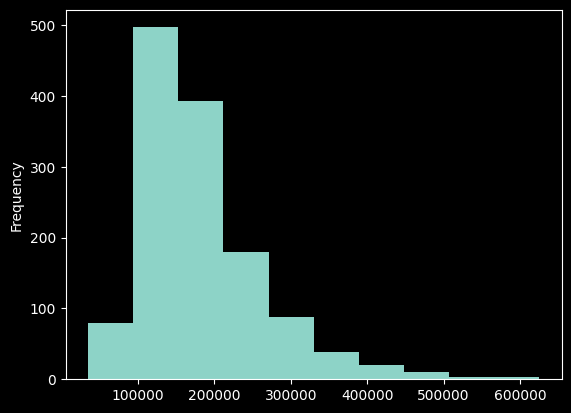

In [17]:
y_train.plot.hist()

Training on such targets is possible, but very large target values easily risk overflow, particularly when a loss function like mean squared error is used. We will use the log-transform to transform this distribution, as it's near-exponential, so it should bring it closer to normal, and also greatly reduce the values range.

Of course, we will need to transform the network predictions back again to evaluate them.

<Axes: ylabel='Frequency'>

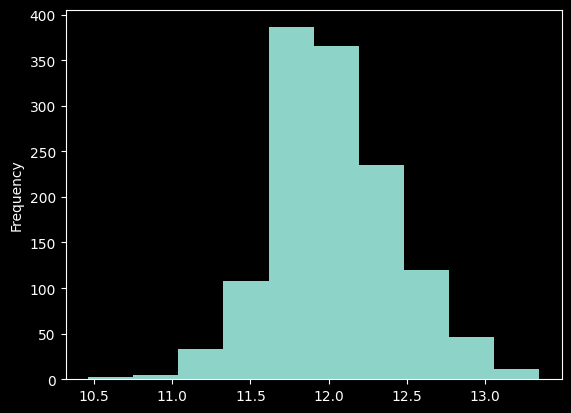

In [18]:
y_train_log = np.log1p(y_train)

pd.Series(y_train_log).plot.hist()

### 3.2 Define and train the model

Since we have tabular data, we will use a simple 2-layer multilayer perceptron (MLP).

In [19]:
class HousePriceNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout_rate=0.2):
        super(HousePriceNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

For training, we will check both the 5-fold CV performance, and the traditional train-test split. Cross-validation will give us an additional, robust performance estimation, as well as standard deviation, which is useful for comparing performances of different models. After all, if the difference between models would be within one standard deviation, it wouldn't really be meaningful.


In [20]:
import torch.nn as nn


class PyTorchTrainer:
    def __init__(
        self, model_class: type[nn.Module], config: dict
    ):
        required_keys = ['hidden_units', 'dropout', 'batch_size', 'learning_rate', 
                         'log_interval', 'epochs', 'name']
        missing = [key for key in required_keys if key not in config]
        if missing:
            raise ValueError(f"Missing required config keys: {missing}")
        
        self.model_class = model_class
        self.config = config

    def create_model(self, input_dim: int) -> nn.Module:
        return self.model_class(
            input_dim=input_dim,
            hidden_dim=self.config["hidden_units"],
            dropout_rate=self.config["dropout"],
        )

    def create_data_loader(
        self, X: torch.Tensor, y: torch.Tensor, shuffle: bool = True
    ) -> DataLoader:
        dataset = TensorDataset(X, y)
        return DataLoader(
            dataset, batch_size=self.config["batch_size"], shuffle=shuffle
        )

    def train_epoch(
        self,
        model: nn.Module,
        train_loader: DataLoader,
        criterion: nn.Module,
        optimizer: optim.Optimizer,
    ) -> float:
        model.train()
        epoch_loss = 0.0
        batch_count = 0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            batch_count += 1

        return epoch_loss / batch_count

    def train_model(
        self,
        model: nn.Module,
        train_loader: DataLoader,
        epochs: int,
        metric_prefix: str = "",
    ) -> None:
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=self.config["learning_rate"])

        for epoch in range(epochs):
            avg_mse = self.train_epoch(model, train_loader, criterion, optimizer)

            if epoch % self.config["log_interval"] == 0:
                metric_name = (
                    f"{metric_prefix}train_mse" if metric_prefix else "train_mse"
                )
                # manually log metric value, with a given name and step value
                mlflow.log_metric(metric_name, avg_mse, step=epoch)

    @torch.no_grad()
    def evaluate_model(
        self,
        model: nn.Module,
        X: torch.Tensor,
        y_test: torch.Tensor,
        log_prefix: str = "",
    ) -> dict[str, float]:
        model.eval()
        
        y_pred_norm = model(X)

        # revert the logarithm with exponent
        y_pred = np.expm1(y_pred_norm.numpy())
        y_test = y_test.numpy()

        rmse = root_mean_squared_error(y_test.ravel(), y_pred.ravel())
        mae = mean_absolute_error(y_test.ravel(), y_pred.ravel())
        r2 = r2_score(y_test.ravel(), y_pred.ravel())

        if log_prefix:
            # manually log metrics that we want
            mlflow.log_metric(f"{log_prefix}_rmse", rmse)
            mlflow.log_metric(f"{log_prefix}_mae", mae)
            mlflow.log_metric(f"{log_prefix}_r2", r2)

        return {"rmse": rmse, "mae": mae, "r2": r2}

    def run_cross_validation(
        self, X_train: torch.Tensor, y_train: torch.Tensor, n_splits: int = 5
    ) -> tuple[float, float, list[float]]:
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        cv_scores = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
            print(f"\nTraining Fold {fold + 1}/{n_splits}...")

            X_fold_train = X_train[train_idx]
            y_fold_train = y_train[train_idx]
            X_fold_val = X_train[val_idx]
            y_fold_val = y_train[val_idx]

            fold_model = self.create_model(X_train.shape[1])
            fold_loader = self.create_data_loader(X_fold_train, y_fold_train)

            self.train_model(
                fold_model,
                fold_loader,
                self.config["epochs"],
                metric_prefix=f"fold_{fold + 1}_",
            )

            # transform validation data with exponent back to original unit
            y_fold_val = np.expm1(y_fold_val)
            
            val_metrics = self.evaluate_model(
                fold_model, X_fold_val, y_fold_val, log_prefix=f"fold_{fold + 1}_val"
            )

            cv_scores.append(val_metrics["r2"])
            print(
                f"  Fold {fold + 1} "
                f"Validation - RMSE: {val_metrics['rmse']:.2f}, "
                f"MAE: {val_metrics['mae']:.2f} "
                f"R^2: {val_metrics['r2']:.3f}"
            )

        return np.mean(cv_scores), np.std(cv_scores), cv_scores

    def _log_dvc_metadata(self, dvc_file_path: str = 'data/ames_data_2006_2008.parquet.dvc'):
        try:
            dvc_metadata = get_dvc_metadata(dvc_file_path)
            
            mlflow.log_param("data_dvc_md5", dvc_metadata['md5'])
            mlflow.log_param("data_dvc_size", dvc_metadata['size'])
            mlflow.log_param("data_path", dvc_metadata['path'])
            print(f"Logged DVC metadata: {dvc_metadata['md5'][:8]}...")
        except FileNotFoundError:
            print("DVC file not found - skipping metadata logging")
        except Exception as e:
            print(f"Could not log DVC metadata: {e}")

    def fit(
        self,
        X_train: pd.DataFrame | np.ndarray,
        y_train: pd.Series | np.ndarray,
        X_test: pd.DataFrame | np.ndarray,
        y_test: pd.Series | np.ndarray,
    ) -> dict:
        X_train, X_test, y_train, y_test = self._prepare_tensors(
            X_train, X_test, y_train, y_test
        )

        with mlflow.start_run(run_name=self.config["name"]):
            mlflow.log_params(self.config)
            
            # Log DVC metadata for data versioning
            self._log_dvc_metadata()

            print(f"Starting 5-fold cross-validation for {self.config['name']}...")
            cv_mean, cv_std, cv_scores = self.run_cross_validation(X_train, y_train)

            mlflow.log_metric("cv_r2_mean", cv_mean)
            mlflow.log_metric("cv_r2_std", cv_std)

            print(
                f"\nCross-validation complete. Mean R^2: {cv_mean:.3f} (+/- {cv_std:.3f})"
            )
            print("\nTraining final model on all training data...")

            final_model = self.create_model(X_train.shape[1])
            final_loader = self.create_data_loader(X_train, y_train)

            self.train_model(
                final_model,
                final_loader,
                self.config["epochs"],
                metric_prefix="final_model_",
            )

            print("\nEvaluating on test set...")
            test_metrics = self.evaluate_model(final_model, X_test, y_test)

            mlflow.log_metric("test_rmse", test_metrics["rmse"])
            mlflow.log_metric("test_mae", test_metrics["mae"])
            mlflow.log_metric("test_r2", test_metrics["r2"])

            self._print_results(test_metrics, cv_mean, cv_std)

            return {
                "rmse": test_metrics["rmse"],
                "mae": test_metrics["mae"],
                "r2": test_metrics["r2"],
                "cv_r2_mean": cv_mean,
                "cv_r2_std": cv_std,
                "cv_scores": cv_scores,
            }

    def _prepare_tensors(self, X_train, X_test, y_train, y_test) -> tuple:
        y_train = np.array(y_train)
        y_test = np.array(y_test)
        
        X_train_tensor = torch.FloatTensor(X_train)
        y_train_tensor = torch.FloatTensor(y_train.reshape(-1, 1))
        
        X_test_tensor = torch.FloatTensor(X_test)
        y_test_tensor = torch.FloatTensor(y_test.reshape(-1, 1))

        print(f"Training samples: {X_train_tensor.shape[0]}")
        print(f"Input features: {X_train_tensor.shape[1]}")
        
        return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor
    
    def _print_results(
        self, test_metrics: dict[str, float], cv_mean: float, cv_std: float
    ) -> None:
        print(f"{'=' * 50}\n")
        print(f"  Mean R^2: {cv_mean:.3f} (+/- {cv_std:.3f})")
        print("\nCross-Validation Performance:")
        print(f"  R^2: {test_metrics['r2']:.3f}")
        print(f"  RMSE: {test_metrics['rmse']:.2f}")
        print(f"  MAE: {test_metrics['mae']:.2f}")
        print("Test Set Performance:")
        print(f"{'=' * 50}")
        print(f"FINAL RESULTS for {self.config['name']}:")
        print(f"\n{'=' * 50}")

Quite a bit of code there! So now let's train the model.

### Configuration 
`base_config` contains **fixed parameters** that stay the same across all experiments:
- `model_class`: The neural network architecture we're using (HousePriceNet)
- `random_seed`: For reproducibility (42)
- `log_interval`: How often to log metrics during training (every 5 epochs)
- `num_samples`: Dataset size
- `input_features`: Number of input features
- `k_folds`: Number of cross-validation folds (5)

`experiment_config` contains **hyperparameters** we want to tune:
- `name`: Unique identifier for this experiment run
- `hidden_units`: Size of the hidden layer (128, 256, 512, etc.)
- `dropout`: Dropout rate for regularization (0.0 to 0.5)
- `learning_rate`: Step size for gradient descent (0.001 to 0.1)
- `epochs`: Number of training iterations (50, 100, 150, etc.)
- `batch_size`: Number of samples per training batch (16, 32, 64, etc.)

If you want you can deliver your own NeuralNetwork model, and just specify in experiment_config: `{"model_class": YourOwnModel}` it will overwrite the our base `HousePriceNet`


#### 3. Merging configurations
We use Python's dictionary merge operator `|` to combine them:
```python
training_config = base_config | experiment_config
```

This creates a single configuration dictionary with all parameters. The `experiment_config` values override any duplicate keys from `base_config`, allowing us to easily experiment with different hyperparameters while keeping the base setup constant.

Now let's set up our first experiment:


In [21]:
base_config = {
    "model_class": HousePriceNet,
    "random_seed": 42,
    "log_interval": 5,
    "num_samples": X_train.shape[0],
    "input_features": X_train.shape[1],
    "k_folds": 5,
}

experiment_config = {
    "name": "first_run",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

In [22]:
training_config = base_config | experiment_config

trainer = PyTorchTrainer(training_config["model_class"], training_config)
trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for first_run...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 22115.48, MAE: 16230.94 R^2: 0.911

Training Fold 2/5...
  Fold 2 Validation - RMSE: 45812.87, MAE: 31045.90 R^2: 0.651

Training Fold 3/5...
  Fold 3 Validation - RMSE: 33612.98, MAE: 24387.26 R^2: 0.794

Training Fold 4/5...
  Fold 4 Validation - RMSE: 33398.63, MAE: 25956.98 R^2: 0.857

Training Fold 5/5...
  Fold 5 Validation - RMSE: 26981.12, MAE: 18390.75 R^2: 0.891

Cross-validation complete. Mean R^2: 0.821 (+/- 0.094)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.821 (+/- 0.094)

Cross-Validation Performance:
  R^2: 0.892
  RMSE: 24856.02
  MAE: 17621.22
Test Set Performance:
FINAL RESULTS for first_run:

🏃 View run first_run at: http://localhost:5001/#/experiments/2/runs/f38a789c68fa49929b478666c628029d
🧪 View experiment at: http://localhost:5001/#/experiments/2

{'rmse': 24856.021484375,
 'mae': 17621.224609375,
 'r2': 0.8918699026107788,
 'cv_r2_mean': np.float64(0.8210755944252014),
 'cv_r2_std': np.float64(0.09376931657102254),
 'cv_scores': [0.9112306237220764,
  0.6510944366455078,
  0.7944540977478027,
  0.8574523329734802,
  0.8911464810371399]}

### Exercise 2

Your task is to:
1. Run 10 experiments by modifying the hyperparameter configuration. Try to improve model performance, which is currently overfitted.
2. Analyze results in MLflow UI.
3. Comment on what changes impacted the model performance the most, and what changes disrupted the training process.
4. Compare the results of our first scikit-learn configuration with the first PyTorch experiments. Do you see any overfitting in the first PyTorch experiment? Explain what signs of overfitting can indicate this situation.

**How to modify configurations:**

You have two approaches:

#### Approach 1: Loop through multiple configurations (Recommended for systematic exploration)

Define a list of experiment configurations and iterate through them. Each configuration dictionary should contain only the hyperparameters you want to tune (name, hidden_units, dropout, learning_rate, epochs, batch_size). The base_config stays the same.

```python
base_config = {
    "model_class": HousePriceNet,  
    "random_seed": 42,             
    "log_interval": 5,             
    "input_features": X_train.shape[1],  # Number of features (181)
    "num_samples": X_train.shape[0],     # Dataset size (1312)
    "target_normalized": True,      
    "k_folds": 5,                  
}

# Define multiple experiments to run
configs = [
    {
        "name": "baseline_128_units",
        "hidden_units": 128,
        "dropout": 0.1,
        "learning_rate": 0.03,
        "epochs": 150,
        "batch_size": 32,
    },
    {
        "name": "larger_network_256",
        "hidden_units": 256,        # Try larger network
        "dropout": 0.2,             # More dropout for regularization
        "learning_rate": 0.01,      # Lower learning rate
        "epochs": 200,
        "batch_size": 64,    
    },
    {
        "name": "high_regularization",
        "hidden_units": 128,
        "dropout": 0.3,             # Even more dropout
        "learning_rate": 0.01,
        "epochs": 150,
        "batch_size": 32,
    },
    # Add 7 more configurations here...
]

# Run all experiments
for experiment_config in configs:
    training_config = base_config | experiment_config 
    
    trainer = PyTorchTrainer(training_config["model_class"], training_config)
    results = trainer.fit(X_train, y_train_log, X_test, y_test)
```

#### Approach 2: Manual and incremental (Good for quick iterations)

Run experiments one by one, adjusting hyperparameters based on previous results:

```python
# First experiment
experiment_config = {
    "name": "experiment_01_baseline",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,    
}

training_config = base_config | experiment_config 
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)
```
After analyzing results in MLflow, run another experiment

```
experiment_config = {
    "name": "experiment_02_more_dropout",
    "hidden_units": 128,
    "dropout": 0.3,  # Increased from 0.1
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,    
}

training_config = base_config | experiment_config 
trainer = PyTorchTrainer(training_config["model_class"], training_config)
results = trainer.fit(X_train, y_train_log, X_test, y_test)

# Continue with more experiments
```


**Tips for hyperparameter tuning:**
- Start with one change at a time to understand its impact
- Use meaningful experiment names that describe what you changed
- Check MLflow UI after each experiment to guide your next choice
- Look for signs of overfitting: high training performance but poor test performance
- Watch the training curves in MLflow's "Model metrics" tab 


### Lab assessment

Fill the code exercises in this Jupyter notebook, and send it with completed exercises, written comments in Markdown cells (particularly for questions in exercise 2), and screenshots of results in MLflow.


### First_run deep analysis

#### Train MSE:
The learning curves show a vary sharp drop in error during the first few epochs followed by an early plateau. This suggests that model quickly fit the training data, but learning proces might have been too aggressive. The oscillations in the 2nd and 4th folds can be caused by a small batch size and outliers, which make the model too sensitive to data split.
![Opis obrazka](screenshots/first_run_train_mse_folds.png)

#### Val_R2:
The significant discrepancy in R2 scores across folds (0.91 (fold 1) and 0.65 (fold 2)) highlights the high sensitivity of the baseline architecture to the data split.
![Opis obrazka](screenshots/first_run_val_r2_folds.png)

#### Val_MAE:
The Mean Absolute Error (MAE) analysis confirms the network's instability. The model's average pricing error ranged from 16k to over 31k depending on the validation subset.
![Opis obrazka](screenshots/first_run_val_mae_folds.png)

Val_RMSE:
The spike in the RMSE value in the 2nd fold (almost 46k) strongly suggests that the baseline model struggled to predict prices for more difficult, atypical cases (outliers) in the validation set.
![Opis obrazka](screenshots/first_run_val_rmse_folds.png)

#### First_run summary:
- Performance (in general): R2 = 0.89 and MAE =17.6k
- Instability: High variance across CV folds (cv_r2_std = 0.093) shows heavy reliance on the data split.
- Overfitting Risk: Low train_mse (0.019) combined with validation instability suggests a slight tendency toward overfitting.


#### Comparison: Gradient Boosting and Ridge Regression (Scikit-learn) vs first_run (PyTorch)
Gradient Boosting and Ridge Regression achieved a much higher and more stable score (GB: cv_r2_mean = 0.893, cv_r2_std = 0.024, RR: cv_r2_mean = 0.880, cv_r2_std = 0.041) compared to first_run model (cv_r2_mean = 0.821, cv_r2_std = 0.094). Scikit-learn algorithms have built-in mechanisms against overfitting (like L2 regularization) but PyTorch networks require manual tuning of parameters to achieve similar stability.


![Opis obrazka](screenshots/scikit-learn_vs_pytorch.png)


#### Next Steps (for experiments):
Focus on reducing model variance and improving training stability.

<u>NOTE: For a full overview of the hyperparameter tuning process, please refer to the final summary table appended at the end of this notebook where key configurations and performance metrics are highlighted.</u>

#### Experiments 1 - 3: Learning Rate Reduction

SUMMARY of Experiments 1 - 3:
- Result: Performance decreased significantly across three runs (cv_r2_mean dropped from baseline 0.821 to 0.506 (exp01), 0.348 (exp02) and 0.657 (exp03). Furthermore cv_r2_std jumped to 0.432 in exp02. Consequently, the test metrics also worsened drastically.
- Conclusion: The drastic drop in performance across all metrics indicates that learning rate reduction without proportionally increasing the number of epochs prevents the model from converging. This proved that a learning rate of 0.03 is optimal for 150-epoch constraint.

**Experiment 1:**
- Change: learning_rate reduction from (baseline) 0.03 to 0.01 and keeping all other parameters constant (hidden_units = 128, dropout = 0.1, epochs = 150).

In [32]:
experiment_config = {
    "name": "exp01_lower_lr_0.01",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.01,
    "epochs": 150,
    "batch_size": 32,
}

In [33]:
training_config = base_config | experiment_config

trainer = PyTorchTrainer(training_config["model_class"], training_config)
trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp01_lower_lr_0.01...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 47880.64, MAE: 38262.88 R^2: 0.584

Training Fold 2/5...
  Fold 2 Validation - RMSE: 60947.59, MAE: 48535.66 R^2: 0.382

Training Fold 3/5...
  Fold 3 Validation - RMSE: 71672.56, MAE: 40660.02 R^2: 0.065

Training Fold 4/5...
  Fold 4 Validation - RMSE: 48392.97, MAE: 37306.05 R^2: 0.701

Training Fold 5/5...
  Fold 5 Validation - RMSE: 36637.36, MAE: 26189.60 R^2: 0.799

Cross-validation complete. Mean R^2: 0.506 (+/- 0.261)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.506 (+/- 0.261)

Cross-Validation Performance:
  R^2: 0.745
  RMSE: 38180.66
  MAE: 27956.84
Test Set Performance:
FINAL RESULTS for exp01_lower_lr_0.01:

🏃 View run exp01_lower_lr_0.01 at: http://localhost:5001/#/experiments/2/runs/2a2d370b04f2424b97b8d78d60d5b4b0
🧪 View experiment at: http://

{'rmse': 38180.66015625,
 'mae': 27956.84375,
 'r2': 0.744864821434021,
 'cv_r2_mean': np.float64(0.5063729405403137),
 'cv_r2_std': np.float64(0.2605155711706228),
 'cv_scores': [0.5839071273803711,
  0.38248711824417114,
  0.06545436382293701,
  0.7007269859313965,
  0.7992891073226929]}

**Experiment 2:**
- Change: learning_rate reduction from (baseline) 0.03 to 0.001 and keeping all other parameters constant (hidden_units = 128, dropout = 0.1, epochs = 150).

In [34]:
experiment_config = {
    "name": "exp02_lower_lr_0.001",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.001,
    "epochs": 150,
    "batch_size": 32,
}

In [35]:
training_config = base_config | experiment_config

trainer = PyTorchTrainer(training_config["model_class"], training_config)
trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp02_lower_lr_0.001...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 73748.30, MAE: 55637.63 R^2: 0.013

Training Fold 2/5...
  Fold 2 Validation - RMSE: 43927.79, MAE: 32440.68 R^2: 0.679

Training Fold 3/5...
  Fold 3 Validation - RMSE: 85817.98, MAE: 42826.43 R^2: -0.340

Training Fold 4/5...
  Fold 4 Validation - RMSE: 47836.97, MAE: 34928.39 R^2: 0.708

Training Fold 5/5...
  Fold 5 Validation - RMSE: 46393.77, MAE: 35615.52 R^2: 0.678

Cross-validation complete. Mean R^2: 0.348 (+/- 0.432)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.348 (+/- 0.432)

Cross-Validation Performance:
  R^2: 0.418
  RMSE: 57680.49
  MAE: 40085.12
Test Set Performance:
FINAL RESULTS for exp02_lower_lr_0.001:

🏃 View run exp02_lower_lr_0.001 at: http://localhost:5001/#/experiments/2/runs/2d08af9641a44cb589c42d57e05f0bd7
🧪 View experiment at: htt

{'rmse': 57680.4921875,
 'mae': 40085.1171875,
 'r2': 0.41770732402801514,
 'cv_r2_mean': np.float64(0.34759504795074464),
 'cv_r2_std': np.float64(0.4320702679199704),
 'cv_scores': [0.012869775295257568,
  0.6792168617248535,
  -0.33983445167541504,
  0.7075643539428711,
  0.678158700466156]}

**Experiment 3:**
- Change: learning_rate reduction from (baseline) 0.03 to 0.005 and keeping all other parameters constant (hidden_units = 128, dropout = 0.1, epochs = 150).

In [38]:
experiment_config = {
    "name": "exp03_lower_lr_0.005",
    "hidden_units": 128,
    "dropout": 0.1,
    "learning_rate": 0.005,
    "epochs": 150,
    "batch_size": 32,
}

In [39]:
training_config = base_config | experiment_config

trainer = PyTorchTrainer(training_config["model_class"], training_config)
trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp03_lower_lr_0.005...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 43985.61, MAE: 32053.57 R^2: 0.649

Training Fold 2/5...
  Fold 2 Validation - RMSE: 44337.58, MAE: 29927.81 R^2: 0.673

Training Fold 3/5...
  Fold 3 Validation - RMSE: 52059.82, MAE: 33113.45 R^2: 0.507

Training Fold 4/5...
  Fold 4 Validation - RMSE: 50076.80, MAE: 34779.28 R^2: 0.680

Training Fold 5/5...
  Fold 5 Validation - RMSE: 38569.11, MAE: 29331.92 R^2: 0.778

Cross-validation complete. Mean R^2: 0.657 (+/- 0.087)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.657 (+/- 0.087)

Cross-Validation Performance:
  R^2: 0.394
  RMSE: 58846.15
  MAE: 41535.43
Test Set Performance:
FINAL RESULTS for exp03_lower_lr_0.005:

🏃 View run exp03_lower_lr_0.005 at: http://localhost:5001/#/experiments/2/runs/f72cad939eec48349e44365fc80b81a5
🧪 View experiment at: http

{'rmse': 58846.1484375,
 'mae': 41535.42578125,
 'r2': 0.39393460750579834,
 'cv_r2_mean': np.float64(0.6572197198867797),
 'cv_r2_std': np.float64(0.08705277114197454),
 'cv_scores': [0.6488509178161621,
  0.6732039451599121,
  0.5069396495819092,
  0.6795383095741272,
  0.7775657773017883]}

#### Experiments 4 - 6: Adjusting Network Architecture

SUMMARY of Experiments 4 - 6:
- Result: Larger networks (hidden_units 256 and 512) degraded performance, cv_r2_mean dropped from (baseline) 0.821 to (exp05) 0.602 and drastically dropped to (exp06) 0.100. On the other hand, smaller network with 64 hidden units achieved a high cv_r2_mean 0.897 (exp04) with lower cv_r2_std 0.035 (exo04).
- Conclusion: The dataset doesn't require complex network architecture. Model with 64 hidden units resolved first_run instability. Oversized models (models with 256 and 512 neurons) severely overfit, which is evidenced by spike in fold variance (cv_r2_std = 0.523 (exp06)) and degradation of test data metrics (test_mae > 31k) despite low final_model_train_mse 0.049 (exp06).

**Experiment 4:**
- Change: number of hidden units in the neural network layer modified from (baseline) 128 to 64 and keeping all other parameters (learning_rate=0.03, dropout=0.1, and epochs=150.

In [46]:
experiment_config = {
    "name": "exp04_smaller_network_64",
    "hidden_units": 64,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

In [47]:
training_config = base_config | experiment_config

trainer = PyTorchTrainer(training_config["model_class"], training_config)
trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp04_smaller_network_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 20392.91, MAE: 14502.56 R^2: 0.925

Training Fold 2/5...
  Fold 2 Validation - RMSE: 32277.22, MAE: 22937.73 R^2: 0.827

Training Fold 3/5...
  Fold 3 Validation - RMSE: 23111.32, MAE: 14384.59 R^2: 0.903

Training Fold 4/5...
  Fold 4 Validation - RMSE: 25996.20, MAE: 17634.04 R^2: 0.914

Training Fold 5/5...
  Fold 5 Validation - RMSE: 23420.43, MAE: 15521.69 R^2: 0.918

Cross-validation complete. Mean R^2: 0.897 (+/- 0.036)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.897 (+/- 0.036)

Cross-Validation Performance:
  R^2: 0.857
  RMSE: 28589.53
  MAE: 19942.41
Test Set Performance:
FINAL RESULTS for exp04_smaller_network_64:

🏃 View run exp04_smaller_network_64 at: http://localhost:5001/#/experiments/2/runs/61c095642f0042dca67d53c583e0dd63
🧪 View experim

{'rmse': 28589.53125,
 'mae': 19942.40625,
 'r2': 0.8569468259811401,
 'cv_r2_mean': np.float64(0.8971552610397339),
 'cv_r2_std': np.float64(0.035874863253602035),
 'cv_scores': [0.9245205521583557,
  0.8268090486526489,
  0.9028273224830627,
  0.9136379957199097,
  0.9179813861846924]}

**Experiment 5:**
- Change: number of hidden units in the neural network layer modified from (baseline) 128 to 256 and keeping all other parameters (learning_rate=0.03, dropout=0.1, and epochs=150.

In [52]:
experiment_config = {
    "name": "exp05_larger_network_256",
    "hidden_units": 256,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

In [53]:
training_config = base_config | experiment_config

trainer = PyTorchTrainer(training_config["model_class"], training_config)
trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp05_larger_network_256...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 35839.00, MAE: 29138.33 R^2: 0.767

Training Fold 2/5...
  Fold 2 Validation - RMSE: 31652.84, MAE: 22899.83 R^2: 0.833

Training Fold 3/5...
  Fold 3 Validation - RMSE: 31240.35, MAE: 22096.07 R^2: 0.822

Training Fold 4/5...
  Fold 4 Validation - RMSE: 101413.07, MAE: 67633.16 R^2: -0.314

Training Fold 5/5...
  Fold 5 Validation - RMSE: 25219.28, MAE: 18405.71 R^2: 0.905

Cross-validation complete. Mean R^2: 0.603 (+/- 0.461)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.603 (+/- 0.461)

Cross-Validation Performance:
  R^2: 0.733
  RMSE: 39072.05
  MAE: 27145.96
Test Set Performance:
FINAL RESULTS for exp05_larger_network_256:

🏃 View run exp05_larger_network_256 at: http://localhost:5001/#/experiments/2/runs/7b525a84dc504634bf62ceca00240a10
🧪 View exper

{'rmse': 39072.05078125,
 'mae': 27145.955078125,
 'r2': 0.7328127026557922,
 'cv_r2_mean': np.float64(0.6026760935783386),
 'cv_r2_std': np.float64(0.46058212238622087),
 'cv_scores': [0.7668785452842712,
  0.8334448337554932,
  0.822447657585144,
  -0.3142889738082886,
  0.9048984050750732]}

**Experiment 6:**
- Change: number of hidden units in the neural network layer modified from (baseline) 128 to 512 and keeping all other parameters (learning_rate=0.03, dropout=0.1, and epochs=150.

In [54]:
experiment_config = {
    "name": "exp06_larger_network_512",
    "hidden_units": 512,
    "dropout": 0.1,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

In [55]:
training_config = base_config | experiment_config

trainer = PyTorchTrainer(training_config["model_class"], training_config)
trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp06_larger_network_512...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 38059.04, MAE: 26262.62 R^2: 0.737

Training Fold 2/5...
  Fold 2 Validation - RMSE: 88290.56, MAE: 63767.78 R^2: -0.296

Training Fold 3/5...
  Fold 3 Validation - RMSE: 66627.49, MAE: 57509.25 R^2: 0.192

Training Fold 4/5...
  Fold 4 Validation - RMSE: 114559.77, MAE: 87895.92 R^2: -0.677

Training Fold 5/5...
  Fold 5 Validation - RMSE: 55248.99, MAE: 40441.66 R^2: 0.544

Cross-validation complete. Mean R^2: 0.100 (+/- 0.524)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.100 (+/- 0.524)

Cross-Validation Performance:
  R^2: 0.647
  RMSE: 44929.89
  MAE: 31888.32
Test Set Performance:
FINAL RESULTS for exp06_larger_network_512:

🏃 View run exp06_larger_network_512 at: http://localhost:5001/#/experiments/2/runs/865e82d001e5487994b9ec165c3040e9
🧪 View expe

{'rmse': 44929.890625,
 'mae': 31888.322265625,
 'r2': 0.6466914415359497,
 'cv_r2_mean': np.float64(0.1000128984451294),
 'cv_r2_std': np.float64(0.5238015347698762),
 'cv_scores': [0.7371028661727905,
  -0.29586994647979736,
  0.19239020347595215,
  -0.6771318912506104,
  0.543573260307312]}

#### Experiments 7 - 9: Optimizing Dropout Rate

SUMMARY of Experiments 7 - 9:
- Result: Testing dropout rates 0.0 (exp07), 0.2 (exp08), and 0.3 (exp09) revealed that 0.2 (exp08) is the best set up, achieving high cv_r2_mean 0.918 and low variance cv_r2_std = 0.011. Removing dropout (exp07) caused a collapse in performance (cv_r2_mean dropped to 0.538 (exp07), test_mae soared to over 32k (exp07) due to overfitting. Increasing dropout to 0.3 (exp09) began to degrade results (cv_r2_mean dropped to 0.889 comparing to 0.918 (exp08)).
- Conclusion: A dropout rate 0.2 is optimal for this dataset.

**Experiment 7:**
- Change: no dropout

In [56]:
experiment_config = {
    "name": "exp07_no_dropout",
    "hidden_units": 128,
    "dropout": 0.0,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

In [57]:
training_config = base_config | experiment_config

trainer = PyTorchTrainer(training_config["model_class"], training_config)
trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp07_no_dropout...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 60140.07, MAE: 41074.60 R^2: 0.344

Training Fold 2/5...
  Fold 2 Validation - RMSE: 50514.43, MAE: 33168.16 R^2: 0.576

Training Fold 3/5...
  Fold 3 Validation - RMSE: 49990.99, MAE: 31261.26 R^2: 0.545

Training Fold 4/5...
  Fold 4 Validation - RMSE: 58257.14, MAE: 38936.22 R^2: 0.566

Training Fold 5/5...
  Fold 5 Validation - RMSE: 47628.05, MAE: 32592.33 R^2: 0.661

Cross-validation complete. Mean R^2: 0.538 (+/- 0.105)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.538 (+/- 0.105)

Cross-Validation Performance:
  R^2: 0.623
  RMSE: 46416.45
  MAE: 32654.41
Test Set Performance:
FINAL RESULTS for exp07_no_dropout:

🏃 View run exp07_no_dropout at: http://localhost:5001/#/experiments/2/runs/da467a631c4a4bbfb9ea8b8a981eb8d5
🧪 View experiment at: http://localhost

{'rmse': 46416.4453125,
 'mae': 32654.408203125,
 'r2': 0.6229254603385925,
 'cv_r2_mean': np.float64(0.5383610248565673),
 'cv_r2_std': np.float64(0.1050457190948727),
 'cv_scores': [0.343555212020874,
  0.575806736946106,
  0.5453490018844604,
  0.5662881731987,
  0.6608060002326965]}

**Experiment 8:**
- Change: dropout = 0.2

In [61]:
experiment_config = {
    "name": "exp08_more_dropout_0.2",
    "hidden_units": 128,
    "dropout": 0.2,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

In [62]:
training_config = base_config | experiment_config

trainer = PyTorchTrainer(training_config["model_class"], training_config)
trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp08_more_dropout_0.2...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 20185.41, MAE: 15157.46 R^2: 0.926

Training Fold 2/5...
  Fold 2 Validation - RMSE: 20399.17, MAE: 14546.30 R^2: 0.931

Training Fold 3/5...
  Fold 3 Validation - RMSE: 23325.13, MAE: 15269.38 R^2: 0.901

Training Fold 4/5...
  Fold 4 Validation - RMSE: 26402.52, MAE: 18200.77 R^2: 0.911

Training Fold 5/5...
  Fold 5 Validation - RMSE: 22931.08, MAE: 15575.73 R^2: 0.921

Cross-validation complete. Mean R^2: 0.918 (+/- 0.011)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.918 (+/- 0.011)

Cross-Validation Performance:
  R^2: 0.887
  RMSE: 25380.62
  MAE: 17749.04
Test Set Performance:
FINAL RESULTS for exp08_more_dropout_0.2:

🏃 View run exp08_more_dropout_0.2 at: http://localhost:5001/#/experiments/2/runs/a10ad1fac73746aa843e8b73d584188d
🧪 View experiment at

{'rmse': 25380.623046875,
 'mae': 17749.03515625,
 'r2': 0.8872573971748352,
 'cv_r2_mean': np.float64(0.9180367469787598),
 'cv_r2_std': np.float64(0.010761493165175808),
 'cv_scores': [0.926048755645752,
  0.9308236241340637,
  0.9010210633277893,
  0.9109172224998474,
  0.9213730692863464]}

**Experiment 9:**
- Change: dropout = 0.3

In [63]:
experiment_config = {
    "name": "exp09_more_dropout_0.3",
    "hidden_units": 128,
    "dropout": 0.3,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

In [64]:
training_config = base_config | experiment_config

trainer = PyTorchTrainer(training_config["model_class"], training_config)
trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp09_more_dropout_0.3...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 22039.48, MAE: 14613.11 R^2: 0.912

Training Fold 2/5...
  Fold 2 Validation - RMSE: 21556.27, MAE: 15904.04 R^2: 0.923

Training Fold 3/5...
  Fold 3 Validation - RMSE: 34972.63, MAE: 23861.89 R^2: 0.777

Training Fold 4/5...
  Fold 4 Validation - RMSE: 24990.18, MAE: 17112.49 R^2: 0.920

Training Fold 5/5...
  Fold 5 Validation - RMSE: 24477.45, MAE: 17515.95 R^2: 0.910

Cross-validation complete. Mean R^2: 0.889 (+/- 0.056)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.889 (+/- 0.056)

Cross-Validation Performance:
  R^2: 0.848
  RMSE: 29450.78
  MAE: 19601.85
Test Set Performance:
FINAL RESULTS for exp09_more_dropout_0.3:

🏃 View run exp09_more_dropout_0.3 at: http://localhost:5001/#/experiments/2/runs/dccbdcd4e1d6447abe5710fe77e0e874
🧪 View experiment at

{'rmse': 29450.779296875,
 'mae': 19601.853515625,
 'r2': 0.8481981754302979,
 'cv_r2_mean': np.float64(0.8885371804237365),
 'cv_r2_std': np.float64(0.055724281834072874),
 'cv_scores': [0.9118397235870361,
  0.9227532744407654,
  0.7774890661239624,
  0.9201928377151489,
  0.91041100025177]}

#### Experiment 10: Based on prior results next experiment combines dropout rate 0.2 with network's architecture 64 to achieve a more robust and generalized model.

**Experiment 10:**
- Change: dropout = 0.02 and hidden_units = 64

SUMMARY of Experiment 10:
- Result: This configuration achieved a strong cv_r2_mean 0.898 with a very low standard deviation of 0.028. Additionally, it generalized well to test data, delivering a solid test_mae = 17k and a test_r2 = 0.893.
- Conclusion: Integration smaller network (64 hidden units) with more regularization (dropout = 0.2) succesfully eliminated first_run instability.

In [67]:
experiment_config = {
    "name": "exp10_network_64_dropout_0.2",
    "hidden_units": 64,
    "dropout": 0.2,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 32,
}

In [68]:
training_config = base_config | experiment_config

trainer = PyTorchTrainer(training_config["model_class"], training_config)
trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp10_network_64_dropout_0.2...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 28525.87, MAE: 21700.76 R^2: 0.852

Training Fold 2/5...
  Fold 2 Validation - RMSE: 21305.49, MAE: 15829.32 R^2: 0.925

Training Fold 3/5...
  Fold 3 Validation - RMSE: 25505.09, MAE: 16113.10 R^2: 0.882

Training Fold 4/5...
  Fold 4 Validation - RMSE: 24644.57, MAE: 16983.13 R^2: 0.922

Training Fold 5/5...
  Fold 5 Validation - RMSE: 24570.75, MAE: 16551.13 R^2: 0.910

Cross-validation complete. Mean R^2: 0.898 (+/- 0.028)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.898 (+/- 0.028)

Cross-Validation Performance:
  R^2: 0.893
  RMSE: 24709.38
  MAE: 17459.32
Test Set Performance:
FINAL RESULTS for exp10_network_64_dropout_0.2:

🏃 View run exp10_network_64_dropout_0.2 at: http://localhost:5001/#/experiments/2/runs/c2a5cfde66574466a46109c07ccabe86
🧪 

{'rmse': 24709.375,
 'mae': 17459.3203125,
 'r2': 0.89314204454422,
 'cv_r2_mean': np.float64(0.8981236577033996),
 'cv_r2_std': np.float64(0.027535715833754058),
 'cv_scores': [0.8523110151290894,
  0.9245401620864868,
  0.8816553950309753,
  0.922385036945343,
  0.9097266793251038]}

#### Experiment 11: Based on prior results next experiment combines parameters from exp10 and batch size 64.

SUMMARY of Experiment 11:
- Result: Doubling the batch size to 64 (comparing exp10) slightly lowered cv_r2_mean to 0.840 but improved test performance, with test_mae dropping to above 15k and test_r2 increase to 0.909.
- Conclusion: While the larger batch size improved generalization, it also caused slight underfitting within 150 epochs.

**Experiment 11:**
- Change: dropout = 0.02, hidden_units = 64 and batch size = 64

In [69]:
experiment_config = {
    "name": "exp11_network_64_dropout_0.2_bs_64",
    "hidden_units": 64,
    "dropout": 0.2,
    "learning_rate": 0.03,
    "epochs": 150,
    "batch_size": 64,
}

In [70]:
training_config = base_config | experiment_config

trainer = PyTorchTrainer(training_config["model_class"], training_config)
trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp11_network_64_dropout_0.2_bs_64...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 24858.46, MAE: 18883.81 R^2: 0.888

Training Fold 2/5...
  Fold 2 Validation - RMSE: 37844.60, MAE: 27792.37 R^2: 0.762

Training Fold 3/5...
  Fold 3 Validation - RMSE: 23922.16, MAE: 15346.55 R^2: 0.896

Training Fold 4/5...
  Fold 4 Validation - RMSE: 38316.97, MAE: 28958.27 R^2: 0.812

Training Fold 5/5...
  Fold 5 Validation - RMSE: 32418.15, MAE: 22114.58 R^2: 0.843

Cross-validation complete. Mean R^2: 0.840 (+/- 0.050)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.840 (+/- 0.050)

Cross-Validation Performance:
  R^2: 0.910
  RMSE: 22692.71
  MAE: 15460.15
Test Set Performance:
FINAL RESULTS for exp11_network_64_dropout_0.2_bs_64:

🏃 View run exp11_network_64_dropout_0.2_bs_64 at: http://localhost:5001/#/experiments/2/runs/49d11a692eed44da8

{'rmse': 22692.70703125,
 'mae': 15460.1513671875,
 'r2': 0.9098727703094482,
 'cv_r2_mean': np.float64(0.8401754856109619),
 'cv_r2_std': np.float64(0.04956162529412899),
 'cv_scores': [0.887844979763031,
  0.7619102597236633,
  0.8958892822265625,
  0.8123773336410522,
  0.8428555727005005]}

#### Experiment 12: Intentional Underfitting (Sanity Check for Epoch Limit)

**Experiment 12:**
- Change: dropout = 0.02, hidden_units = 64, batch size = 64 and learning_rate = 0.01

SUMMARY of Experiment 12:
- Result: As expected, reducing the learning_rate to 0.01 without extending the training time (epochs) led to performance crash with cv_r2_mean = 0.424 and spiking test_mae to over 26k.
- Conclusion: Combining a lower learning_rate with a larger batch_size requires significantly more epochs to converge.

In [71]:
experiment_config = {
    "name": "exp12_network_64_dropout_0.2_bs_64_lr_0.01",
    "hidden_units": 64,
    "dropout": 0.2,
    "learning_rate": 0.01,
    "epochs": 150,
    "batch_size": 64,
}

In [72]:
training_config = base_config | experiment_config

trainer = PyTorchTrainer(training_config["model_class"], training_config)
trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp12_network_64_dropout_0.2_bs_64_lr_0.01...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 52839.17, MAE: 41348.46 R^2: 0.493

Training Fold 2/5...
  Fold 2 Validation - RMSE: 64758.24, MAE: 51619.66 R^2: 0.303

Training Fold 3/5...
  Fold 3 Validation - RMSE: 67026.50, MAE: 48938.19 R^2: 0.183

Training Fold 4/5...
  Fold 4 Validation - RMSE: 68514.59, MAE: 57715.44 R^2: 0.400

Training Fold 5/5...
  Fold 5 Validation - RMSE: 41805.56, MAE: 30307.66 R^2: 0.739

Cross-validation complete. Mean R^2: 0.424 (+/- 0.188)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.424 (+/- 0.188)

Cross-Validation Performance:
  R^2: 0.750
  RMSE: 37765.25
  MAE: 26007.32
Test Set Performance:
FINAL RESULTS for exp12_network_64_dropout_0.2_bs_64_lr_0.01:

🏃 View run exp12_network_64_dropout_0.2_bs_64_lr_0.01 at: http://localhost:5001/#/experiments/

{'rmse': 37765.25390625,
 'mae': 26007.3203125,
 'r2': 0.7503864169120789,
 'cv_r2_mean': np.float64(0.4235178709030151),
 'cv_r2_std': np.float64(0.1883034665378126),
 'cv_scores': [0.49326324462890625,
  0.3028552532196045,
  0.18268823623657227,
  0.4001133441925049,
  0.7386692762374878]}

#### Experiment 13 and 14: Extended Training (400 and 350 epochs)

SUMMARY of Experiments 13 and 14:
- Result: Extending the training time (epochs) to 350 (exp14) and 400 epochs (exp13) completely resolved the underfitting issue. Exp13 achieved the best overall performance: cv_r2_mean = 0.915, very good cross-validation stability cv_r2_std = 0.022 and the best test_mae slightly above 15k. Exp14 performed similarly well, confirming that the model remains stable across extended training periods.
- Conclusion: Exp13 configuration proved to be the optimal architecture, delivering the perfect balance of high predictive accuracy and robust generalization.

**Experiment 13:**
- Change: dropout = 0.02, hidden_units = 64, batch size = 64, learning_rate = 0.01 and epochs = 400

In [75]:
experiment_config = {
    "name": "exp13_net_64_dropout_0.2_bs_64_lr_0.01_epochs_400",
    "hidden_units": 64,
    "dropout": 0.2,
    "learning_rate": 0.01,
    "epochs": 400,
    "batch_size": 64,
}

In [76]:
training_config = base_config | experiment_config

trainer = PyTorchTrainer(training_config["model_class"], training_config)
trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp13_net_64_dropout_0.2_bs_64_lr_0.01_epochs_400...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 19187.88, MAE: 13792.51 R^2: 0.933

Training Fold 2/5...
  Fold 2 Validation - RMSE: 20789.75, MAE: 15589.78 R^2: 0.928

Training Fold 3/5...
  Fold 3 Validation - RMSE: 26155.06, MAE: 16698.32 R^2: 0.876

Training Fold 4/5...
  Fold 4 Validation - RMSE: 23395.06, MAE: 15859.28 R^2: 0.930

Training Fold 5/5...
  Fold 5 Validation - RMSE: 24939.48, MAE: 18456.96 R^2: 0.907

Cross-validation complete. Mean R^2: 0.915 (+/- 0.022)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.915 (+/- 0.022)

Cross-Validation Performance:
  R^2: 0.911
  RMSE: 22546.55
  MAE: 15322.54
Test Set Performance:
FINAL RESULTS for exp13_net_64_dropout_0.2_bs_64_lr_0.01_epochs_400:

🏃 View run exp13_net_64_dropout_0.2_bs_64_lr_0.01_epochs_400 at: http://localhos

{'rmse': 22546.546875,
 'mae': 15322.54296875,
 'r2': 0.9110300540924072,
 'cv_r2_mean': np.float64(0.9147852063179016),
 'cv_r2_std': np.float64(0.02168118646759326),
 'cv_scores': [0.9331772327423096,
  0.9281492233276367,
  0.8755467534065247,
  0.9300558567047119,
  0.9069969654083252]}

**Experiment 14:**
- Change: dropout = 0.02, hidden_units = 64, batch size = 64, learning_rate = 0.01 and epochs = 350

In [79]:
experiment_config = {
    "name": "exp14_net_64_dropout_0.2_bs_64_lr_0.01_epochs_350",
    "hidden_units": 64,
    "dropout": 0.2,
    "learning_rate": 0.01,
    "epochs": 350,
    "batch_size": 64,
}

In [80]:
training_config = base_config | experiment_config

trainer = PyTorchTrainer(training_config["model_class"], training_config)
trainer.fit(X_train, y_train_log, X_test, y_test)

Training samples: 1312
Input features: 181
Logged DVC metadata: f4405333...
Starting 5-fold cross-validation for exp14_net_64_dropout_0.2_bs_64_lr_0.01_epochs_350...

Training Fold 1/5...
  Fold 1 Validation - RMSE: 19796.76, MAE: 14458.16 R^2: 0.929

Training Fold 2/5...
  Fold 2 Validation - RMSE: 19917.61, MAE: 14955.58 R^2: 0.934

Training Fold 3/5...
  Fold 3 Validation - RMSE: 24577.57, MAE: 16462.91 R^2: 0.890

Training Fold 4/5...
  Fold 4 Validation - RMSE: 28312.39, MAE: 20087.83 R^2: 0.898

Training Fold 5/5...
  Fold 5 Validation - RMSE: 26230.86, MAE: 17609.03 R^2: 0.897

Cross-validation complete. Mean R^2: 0.910 (+/- 0.018)

Training final model on all training data...

Evaluating on test set...

  Mean R^2: 0.910 (+/- 0.018)

Cross-Validation Performance:
  R^2: 0.912
  RMSE: 22368.45
  MAE: 15493.77
Test Set Performance:
FINAL RESULTS for exp14_net_64_dropout_0.2_bs_64_lr_0.01_epochs_350:

🏃 View run exp14_net_64_dropout_0.2_bs_64_lr_0.01_epochs_350 at: http://localhos

{'rmse': 22368.447265625,
 'mae': 15493.7666015625,
 'r2': 0.9124300479888916,
 'cv_r2_mean': np.float64(0.9095411539077759),
 'cv_r2_std': np.float64(0.018165193046657216),
 'cv_scores': [0.9288690686225891,
  0.9340510964393616,
  0.8901063799858093,
  0.8975631594657898,
  0.8971160650253296]}

#### FINAL SUMMARY:

The optimization process successfully transformed unstable first_run into a robust final model (exp13).
- Stabilization (exp11): Reducing the network to 64 units, adding 0.2 dropout, and increasing batch size to 64 (keeping learning_rate = 0.03) fixed the variance issue with cv_r2_std dropped to 0.049 and test_mae improved to 15,46k.
- Full Convergence (exp13): Lowering the learning_rate to 0.01 and extending training to 400 epochs unlocked the model's full potential. It achieved the best overall performance: peak cv_r2_mean (0.914), lowest variance (cv_r2_std = 0.021), and the lowest test_mae = 15,32k.

**Below comparison charts provide visual validation of conclusions, confirming that exp13 achieved the smoothest learning process and the most stable, accurate results across all cross-validation folds.**

![cv_r2_mean_std](screenshots/cv_r2_selected.png)

![test_metrics](screenshots/metrics_test_selected.png)

![val_r2](screenshots/metrics_val_r2_folds_selected.png)

![val_mae](screenshots/metrics_val_mae_folds_selected.png)

![val_rmse](screenshots/metrics_val_rmse_folds_selected.png)

![train_mse](screenshots/metrics_train_mse_folds_selected.png)

Final table with all runs:

![table_all_runs](screenshots/final_table_all_val_r2.png)